In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

In [2]:
csv_file = 'Val_5M_inference_with_probs_and_embedding.csv'
df = pd.read_csv(csv_file)

In [3]:
print(f"CSV file '{csv_file}' loaded")
print(f"Total size: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

CSV file 'Val_5M_inference_with_probs_and_embedding.csv' loaded
Total size: 6163.99 MB


In [4]:
X = df[[f"emb_{j}" for j in range(128)]].to_numpy(dtype=np.float32)
y = df["truth_label"].to_numpy(dtype=np.int64)

In [5]:
print("Embeddings:", X.shape, "Labels:", y.shape)

Embeddings: (4999932, 128) Labels: (4999932,)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [7]:
# to tensors
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_ds  = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=512)
test_loader  = DataLoader(test_ds, batch_size=512)

In [8]:
# MLP model
class MLP(nn.Module):
    def __init__(self, input_dim=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)
    # 128 → 256 → 128 → 64 → 10

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_model(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        # print the loss and accuracy for each epoch
        # Training

        model.train()
        train_loss, train_correct = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_correct += (outputs.argmax(1) == yb).sum().item()
        
        epoch_loss_avg = train_loss / len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (outputs.argmax(1) == yb).sum().item()
        
        epoch_val_loss_avg = val_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}: Train Loss {epoch_loss_avg:.4f}, Val Loss {epoch_val_loss_avg:.4f} | Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}")
    print("Training complete.")

In [10]:
train_model(model, train_loader, val_loader, epochs=30)

Epoch 1: Train Loss 0.5880, Val Loss 0.4029 | Train Acc 0.7665, Val Acc 0.8193
Epoch 2: Train Loss 0.3245, Val Loss 0.2444 | Train Acc 0.8761, Val Acc 0.9145
Epoch 3: Train Loss 0.2760, Val Loss 0.2451 | Train Acc 0.8982, Val Acc 0.9083
Epoch 4: Train Loss 0.2474, Val Loss 0.5818 | Train Acc 0.9105, Val Acc 0.7580
Epoch 5: Train Loss 0.2182, Val Loss 0.6797 | Train Acc 0.9214, Val Acc 0.7476
Epoch 6: Train Loss 0.1998, Val Loss 0.1835 | Train Acc 0.9280, Val Acc 0.9355
Epoch 7: Train Loss 0.1979, Val Loss 0.1902 | Train Acc 0.9304, Val Acc 0.9306
Epoch 8: Train Loss 0.1854, Val Loss 0.1121 | Train Acc 0.9361, Val Acc 0.9662
Epoch 9: Train Loss 0.1631, Val Loss 0.0858 | Train Acc 0.9448, Val Acc 0.9748
Epoch 10: Train Loss 0.1528, Val Loss 0.0865 | Train Acc 0.9485, Val Acc 0.9712
Epoch 11: Train Loss 0.1513, Val Loss 0.2971 | Train Acc 0.9501, Val Acc 0.8914
Epoch 12: Train Loss 0.1332, Val Loss 0.0681 | Train Acc 0.9552, Val Acc 0.9796
Epoch 13: Train Loss 0.1350, Val Loss 0.0548 | Tr

In [11]:
# final test
model.eval()
test_correct = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(1)
        test_correct += (preds == yb).sum().item()

print(f"Test Accuracy: {test_correct / len(test_loader.dataset):.4f}")
# add an auc metric
# add loss too

Test Accuracy: 0.9350


In [12]:
from sklearn.metrics import roc_curve, auc

model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_test).float().to(device))
    probs_test = torch.softmax(logits, dim=1).cpu().numpy()

auc_per_class = {}
for i in range(10):
    if np.sum(y_test == i) == 0:
        print(f"Class {i}: no samples in test set, skipping")
        continue
    y_true_bin = (y_test == i).astype(int)
    y_score = probs_test[:, i]   # use test probs
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    auc_per_class[i] = auc(fpr, tpr)
    print(f"Class {i}: AUC = {auc_per_class[i]:.4f}")

Class 0: AUC = 1.0000
Class 1: AUC = 0.9921
Class 2: AUC = 0.9842
Class 3: AUC = 0.9943
Class 4: AUC = 0.9973
Class 5: AUC = 0.9974
Class 6: AUC = 0.9999
Class 7: AUC = 1.0000
Class 8: AUC = 0.9999
Class 9: AUC = 0.9999


In [13]:
print(np.unique(y, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64), array([499968, 499995, 499998, 499987, 499996, 500000, 500000, 500000,
       499989, 499999], dtype=int64))


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss.split(X, y))
X_train, y_train = X[train_idx], y[train_idx]
X_temp, y_temp = X[temp_idx], y[temp_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(sss2.split(X_temp, y_temp))
X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(np.unique(y_test, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64), array([74995, 75000, 74999, 74998, 75000, 75000, 75000, 75000, 74998,
       75000], dtype=int64))


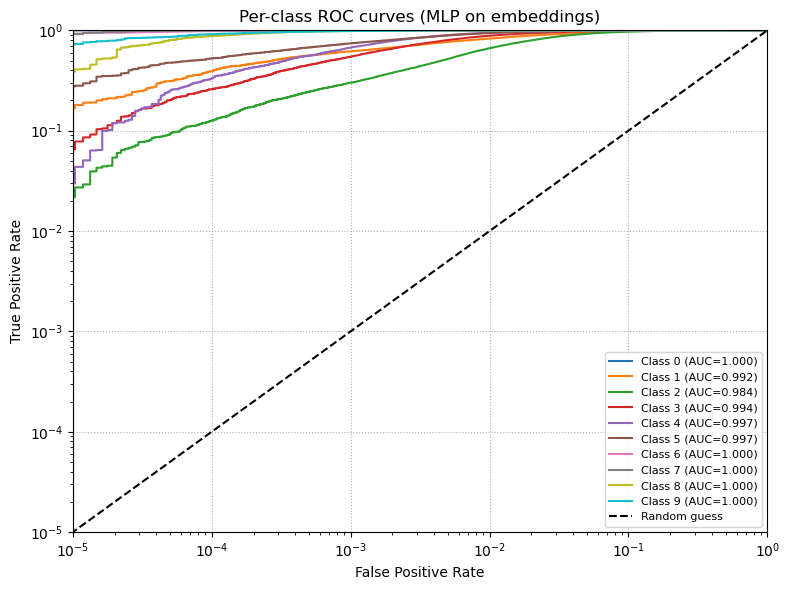

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i in range(10):
    if np.sum(y_test == i) == 0:
        continue
    y_true_bin = (y_test == i).astype(int)
    y_score = probs_test[:, i]
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-class ROC curves (MLP on embeddings)")
# plt.xlim(0, 1)
plt.xlim(1e-5, 1)
plt.ylim(1e-5, 1.0)
# plt.ylim(0,1)
# plt.xscale("linear")
plt.yscale("log")
plt.xscale("log")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, ls=":")
plt.tight_layout()
plt.show()